In [82]:
import pandas as pd

In [83]:
import numpy

In [84]:
df = pd.read_csv('AG_news(train).csv')

In [85]:
df

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."
...,...,...,...
119995,1,Pakistan's Musharraf Says Won't Quit as Army C...,KARACHI (Reuters) - Pakistani President Perve...
119996,2,Renteria signing a top-shelf deal,Red Sox general manager Theo Epstein acknowled...
119997,2,Saban not going to Dolphins yet,The Miami Dolphins will put their courtship of...
119998,2,Today's NFL games,PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: ...


In [86]:
df['text']= df['Title']+" "+df["Description"]

In [87]:
X = df['text']

In [88]:
y =df['Class Index']

In [89]:
from sklearn.model_selection import train_test_split

In [90]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [91]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [92]:
vec = TfidfVectorizer()

In [93]:
X_train = vec.fit_transform(X_train)

In [94]:
X_test = vec.transform(X_test)

In [95]:
from sklearn.linear_model import LogisticRegression

In [96]:
logistic = LogisticRegression(max_iter=100)

In [97]:
logistic.fit(X_train,y_train)


C:\Users\kokar\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [98]:
logi_pred = logistic.predict(X_test)

In [99]:
from sklearn.metrics import classification_report , accuracy_score

In [120]:
nb_acc=accuracy_score(y_test,y_pred)

In [101]:
from sklearn.naive_bayes import MultinomialNB

In [102]:
naive= MultinomialNB()

In [103]:
naive.fit(X_train,y_train)


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [104]:
naive_pred = naive.predict(X_test)

In [121]:
lr_acc=accuracy_score(y_test,y_pred)

In [106]:
from sklearn.ensemble import RandomForestClassifier

In [110]:
random = RandomForestClassifier(n_estimators=10,max_depth=20)

In [111]:
random.fit(X_train,y_train)

,n_estimators,10
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [112]:
random_pred= random.predict(X_test)

In [119]:
rf_acc =accuracy_score(y_test,random_pred)

In [118]:
import matplotlib.pyplot as plt

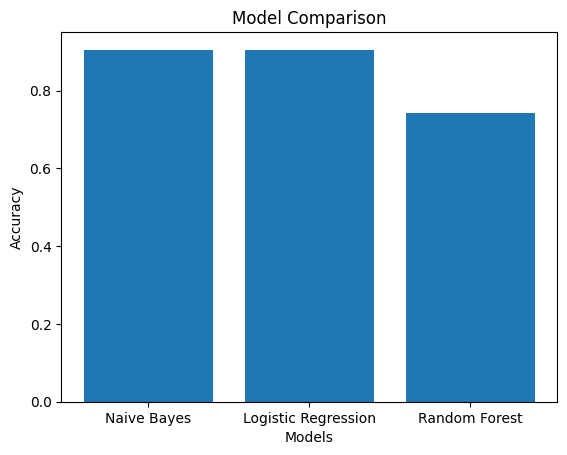

In [122]:
models = ["Naive Bayes", "Logistic Regression", "Random Forest"]
accuracies = [nb_acc, lr_acc, rf_acc]


plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()